# Vermeer: Virtual Staining Demo

This notebook demonstrates **virtual staining** with the Vermeer model.

Vermeer is an autoregressive generative model for multi-channel fluorescent microscopy images, conditioned on protein sequence information. It tokenizes each grayscale channel with a pretrained VQ-VAE, arranges the per-channel codes into a channel-interleaved sequence with learned start-of-channel (SOC) and end-of-channel (EOC) tokens, and predicts the next token with a channel-adaptive transformer conditioned on ESM-C protein embeddings.

**Virtual staining setup.** Given a microscopy image with channels `[nucleus, microtubule, ER, protein]`, we feed the first 3 reference-stain channels plus an ESM-C embedding of the protein of interest as conditioning input, and autoregressively generate the 4th (protein) channel.

## 1. Setup

In [ ]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')

# Make Vermeer importable
REPO_ROOT = "/n/home08/skambhampati/Vermeer/" # Replace this with the path to where you download the repository
sys.path.insert(0, os.path.join(REPO_ROOT, "vermeer"))

from tokenizer.tokenizer_image.vq_model import VQ_models
from autoregressive.models.gpt_ca import GPT_models
from autoregressive.models.generate_ca import (
    generate_with_prefix,
    decode_tokens_to_images,
    load_and_prepare_prefixes,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

## 2. Configuration

Paths to:
- the **VQ-VAE tokenizer** (shared across all Vermeer variants),
- the **Vermeer GPT-L checkpoint** (mean-pooled ESM-2 conditioning, trained on HPA at 256x256), and
- a **validation directory** containing pre-extracted VQ codes and per-image ESM embeddings.

In [2]:
class Args:
    # Vermeer GPT-CA settings
    gpt_model = "GPT-L"
    gpt_ckpt = "/n/netscratch/chenf2011_lab/sandeep/CA_LlamaGen_local_output/452-hpa_split_size_256_lr_1e-4_lin_schedule-GPT-L/checkpoints/0115000.pt"  # change to your path
    # gpt_ckpt = "vermeer_GPT-L/checkpoints/0115000.pt" # Replace this with the path to where you download the model checkpoint
    model_type = "ca_esm_embed_mean_pool"
    precision = "bf16"

    # Channel-adaptive structure
    n_channels = 4               # nucleus, microtubule, ER, protein
    n_max_channels = 4
    block_size_per_channel = 256 # 16x16 patches per channel

    # VQ tokenizer
    vq_model = "VQ-16"
    vq_ckpt = "/n/holylabs/chenf2011_lab/Everyone/Sandeep/code/CA_LlamaGen/pretrained_models/vq_ds16_c2i.pt"  # change to your path
    # vq_ckpt = "/code/CA_LlamaGen/pretrained_models/vq_ds16_c2i.pt" # Replace this with the path to where you download the tokenizer checkpoint
    codebook_size = 16384
    codebook_embed_dim = 8

    # Image
    image_size = 256
    downsample_size = 16

    # Sampling
    temperature = 1.0
    top_k = 2000
    top_p = 1.0
    cfg_scale = 1.0

args = Args()

# Pre-extracted codes/labels for the val1 split
DATA_DIR = "/n/netscratch/chenf2011_lab/sandeep/data/hpa_dataset/hpa_preprocessed_split_256_code_flip_ten_crop_rotate_esm_embed_mean_pool/"  # change to your path
# DATA_DIR = "/data/hpa_dataset/hpa_preprocessed_split_256_code_flip_ten_crop_rotate_esm_embed_mean_pool" # Replace this with the path to where you download the tokenizer checkpoint
VAL_SPLIT = "val1"
VAL_CODE_DIR  = f"{DATA_DIR}/ca{args.image_size}_codes/{VAL_SPLIT}"
VAL_LABEL_DIR = f"{DATA_DIR}/ca{args.image_size}_labels/{VAL_SPLIT}"

tokens_per_channel = args.block_size_per_channel + 2  # SOC + 256 patches + EOC
latent_size = args.image_size // args.downsample_size

## 3. Load the VQ-VAE tokenizer

Each microscopy channel is independently encoded into a 16x16 grid of discrete codes drawn from a shared 16,384-entry codebook.

In [3]:
torch.set_grad_enabled(False)

vq_model = VQ_models[args.vq_model](
    codebook_size=args.codebook_size,
    codebook_embed_dim=args.codebook_embed_dim,
).to(device).eval()

vq_ckpt = torch.load(args.vq_ckpt, map_location="cpu")
vq_model.load_state_dict(vq_ckpt["model"])
del vq_ckpt
print("VQ-VAE tokenizer loaded.")

VQ-VAE tokenizer loaded.


## 4. Load the Vermeer model

GPT-L (343M parameters) with the channel-adaptive vocabulary (base codes + per-channel SOC/EOC + EOS) and mean-pooled ESM-2 conditioning.

In [4]:
precision = {"none": torch.float32, "bf16": torch.bfloat16, "fp16": torch.float16}[args.precision]

gpt_model = GPT_models[args.gpt_model](
    vocab_size=args.codebook_size,
    n_max_channels=args.n_max_channels,
    block_size_per_channel=args.block_size_per_channel,
    model_type=args.model_type,
).to(device=device, dtype=precision).eval()

ckpt = torch.load(args.gpt_ckpt, map_location="cpu", weights_only=False)
if "model" in ckpt:
    state_dict = ckpt["model"]
elif "module" in ckpt:
    state_dict = ckpt["module"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt
gpt_model.load_state_dict(state_dict, strict=False)
del ckpt

print(f"Vermeer ({args.gpt_model}) loaded.")
print(f"  Extended vocab size : {gpt_model.extended_vocab_size}")
print(f"  Tokens per channel  : {tokens_per_channel}  (SOC + {args.block_size_per_channel} codes + EOC)")
print(f"  Channels            : {args.n_channels}")

Vermeer (GPT-L) loaded.
  Extended vocab size : 16393
  Tokens per channel  : 258  (SOC + 256 codes + EOC)
  Channels            : 4


## 5. Load an example image

We pick one validation FOV. The `.npy` file in `ca256_codes/` already contains the VQ tokens for all 4 channels of the image (shape `(num_aug, seq_len)`); the matching file in `ca256_labels/` holds the mean-pooled ESM-2 embedding of the imaged protein.

In [5]:
EXAMPLE_FILENAME = sorted(f for f in os.listdir(VAL_CODE_DIR) if f.endswith(".npy"))[0]
print(f"Example image: {EXAMPLE_FILENAME}")

code = np.load(os.path.join(VAL_CODE_DIR,  EXAMPLE_FILENAME))
label = np.load(os.path.join(VAL_LABEL_DIR, EXAMPLE_FILENAME))

# Pick the first augmentation if the file stores multiple
if code.ndim > 1:
    code = code[0]

print(f"  VQ codes shape    : {code.shape}  (= n_channels x (1 SOC + {args.block_size_per_channel} codes + 1 EOC))")
print(f"  ESM embedding shape: {label.shape}")

Example image: A0A087WSY6_HPA047702_Rh30_fov_1.npy
  VQ codes shape    : (1032,)  (= n_channels x (1 SOC + 256 codes + 1 EOC))
  ESM embedding shape: (1152,)


## 6. Run protein inpainting

We build a prefix containing the first 3 channels of VQ codes, then let Vermeer autoregressively generate the 4th-channel tokens conditioned on the ESM-2 embedding.

In [6]:
import warnings
warnings.filterwarnings('ignore')

n_prefix_channels = 3   # condition on nucleus + microtubule + ER

codes_batch  = code[None]    # (1, seq_len)
labels_batch = label[None]   # (1, embed_dim)

prefix_tokens, _ = load_and_prepare_prefixes(
    codes_batch, labels_batch, n_prefix_channels,
    tokens_per_channel=tokens_per_channel, aug_idx=0, device=device,
)
cond_idx = torch.tensor(labels_batch, dtype=precision).unsqueeze(1).to(device)

generated = generate_with_prefix(
    model=gpt_model,
    cond_idx=cond_idx,
    prefix_tokens=prefix_tokens,
    n_total_channels=args.n_channels,
    tokens_per_channel=tokens_per_channel,
    cfg_scale=args.cfg_scale,
    cfg_interval=-1,
    temperature=args.temperature,
    top_k=args.top_k,
    top_p=args.top_p,
    sample_logits=True,
)

ground_truth = torch.from_numpy(codes_batch).long().to(device)
print(f"Generated tokens   : {tuple(generated.shape)}")
print(f"Ground-truth tokens: {tuple(ground_truth.shape)}")

Generated tokens   : (1, 1033)
Ground-truth tokens: (1, 1032)


## 7. Decode tokens back to images

In [7]:
# generate_with_prefix appends EOS; trim it before decoding
if generated.shape[1] > ground_truth.shape[1]:
    generated = generated[:, :-1]

gen_imgs = decode_tokens_to_images(
    generated, vq_model, args.n_channels, tokens_per_channel,
    latent_size, args.codebook_embed_dim,
).mean(dim=2).detach().cpu()  # (B, n_channels, H, W) — mean over RGB-replication dim

gt_imgs = decode_tokens_to_images(
    ground_truth, vq_model, args.n_channels, tokens_per_channel,
    latent_size, args.codebook_embed_dim,
).mean(dim=2).detach().cpu()

print(f"Generated images   : {tuple(gen_imgs.shape)}")
print(f"Ground-truth images: {tuple(gt_imgs.shape)}")

Generated images   : (1, 4, 256, 256)
Ground-truth images: (1, 4, 256, 256)


## 8. Visualize the inpainting result

Left: the 3 reference stain channels (nucleus / microtubule / ER) shown as an RGB composite — this is what Vermeer sees as input.

Middle: the **ground-truth** protein channel.

Right: the **generated** protein channel, autoregressively sampled by Vermeer conditioned on the ESM-2 embedding of the protein.

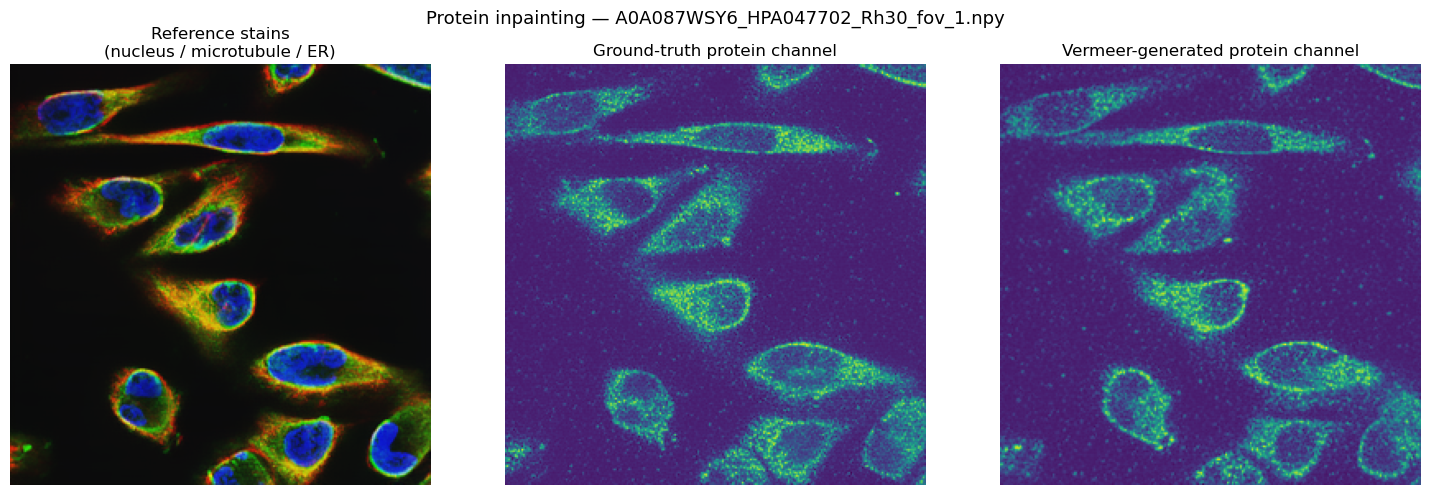

In [8]:
def normalize(img):
    img = img - img.min()
    return img / (img.max() + 1e-8)

# Build RGB composite of the prefix channels (channel 1 -> R, channel 2 -> G, channel 0 -> B)
ref = gt_imgs[0, :3]
rgb = torch.stack([ref[1], ref[2], ref[0]], dim=0).permute(1, 2, 0).numpy()
rgb = normalize(rgb)

gt_protein  = gt_imgs[0, 3].numpy()
gen_protein = gen_imgs[0, 3].numpy()
vmin = min(gt_protein.min(), gen_protein.min())
vmax = max(gt_protein.max(), gen_protein.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Reference stains\n(nucleus / microtubule / ER)")
axes[0].axis("off")

axes[1].imshow(gt_protein, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Ground-truth protein channel")
axes[1].axis("off")

axes[2].imshow(gen_protein, cmap="viridis", vmin=vmin, vmax=vmax)
axes[2].set_title("Vermeer-generated protein channel")
axes[2].axis("off")

fig.suptitle(f"Protein inpainting — {EXAMPLE_FILENAME}", fontsize=13)
plt.tight_layout()
plt.show()